# Day 08. Exercise 04
# Regression

## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error

## 1. Preprocessing

In [2]:
df = pd.read_csv('../data/checker_regression.csv')

In [3]:
df = df.drop(columns=['uid'])

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   num_commits  77 non-null     int64  
 1   pageviews    59 non-null     float64
 2   AVG(diff)    18 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 1.9 KB


In [5]:
df = df.drop_duplicates()

In [6]:
df = df.fillna(0)

In [7]:
X = df[['num_commits', 'pageviews']]
y = df['AVG(diff)']

In [8]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21)

## 2. Crossvalidation

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29 entries, 0 to 76
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   num_commits  29 non-null     int64  
 1   pageviews    29 non-null     float64
 2   AVG(diff)    29 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 928.0 bytes


In [10]:
# Train model
def crossval(n_splits, X, y, model):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=21)
    train_rmse_list = []
    test_rmse_list = []

    for train_index, test_index in kf.split(X):
        X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]
        y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]

        model.fit(X_train_fold, y_train_fold)
        y_train_pred = model.predict(X_train_fold)
        y_test_pred = model.predict(X_test_fold)

        # manually compute RMSE
        rmse_train = np.sqrt(mean_squared_error(y_train_fold, y_train_pred))
        rmse_test = np.sqrt(mean_squared_error(y_test_fold, y_test_pred))

        train_rmse_list.append(rmse_train)
        test_rmse_list.append(rmse_test)

        print(f"train -  {rmse_train:.4f}   |   test -  {rmse_test:.4f}")

    print(f"Average RMSE on crossval is {np.mean(test_rmse_list):.4f}")

In [11]:
print("Linear Regression:")
crossval(10, X, y, LinearRegression())

print("\nDecision Tree:")
crossval(10, X, y, DecisionTreeRegressor(random_state=21))

print("\nRandom Forest:")
crossval(10, X, y, RandomForestRegressor(random_state=21, n_estimators=100))

Linear Regression:
train -  61.3533   |   test -  57.8561
train -  62.5462   |   test -  44.7122
train -  61.1456   |   test -  83.1990
train -  58.4167   |   test -  79.3990
train -  60.1103   |   test -  68.7561
train -  60.6193   |   test -  65.9230
train -  61.7208   |   test -  61.8004
train -  62.6068   |   test -  46.6899
train -  55.5803   |   test -  99.0812
train -  61.5779   |   test -  53.2412
Average RMSE on crossval is 66.0658

Decision Tree:
train -  0.0000   |   test -  117.1772
train -  0.0000   |   test -  79.5333
train -  0.0000   |   test -  0.0000
train -  0.0000   |   test -  78.9866
train -  0.0000   |   test -  101.3671
train -  0.0000   |   test -  35.3884
train -  0.0000   |   test -  0.0000
train -  0.0000   |   test -  69.8101
train -  0.0000   |   test -  117.5295
train -  0.0000   |   test -  40.5879
Average RMSE on crossval is 64.0380

Random Forest:
train -  20.9207   |   test -  97.5034
train -  22.5137   |   test -  78.0169
train -  26.4575   |   test 

## 3. Predictions and evaluation

In [12]:
# Evaluate model
lr_model = LinearRegression()
dt_model = DecisionTreeRegressor(random_state=21)
rf_model = RandomForestRegressor(random_state=21, n_estimators=100)

lr_model.fit(X_train, y_train)
dt_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)


lr_preds = lr_model.predict(X_test)
dt_preds = dt_model.predict(X_test)
rf_preds = rf_model.predict(X_test)


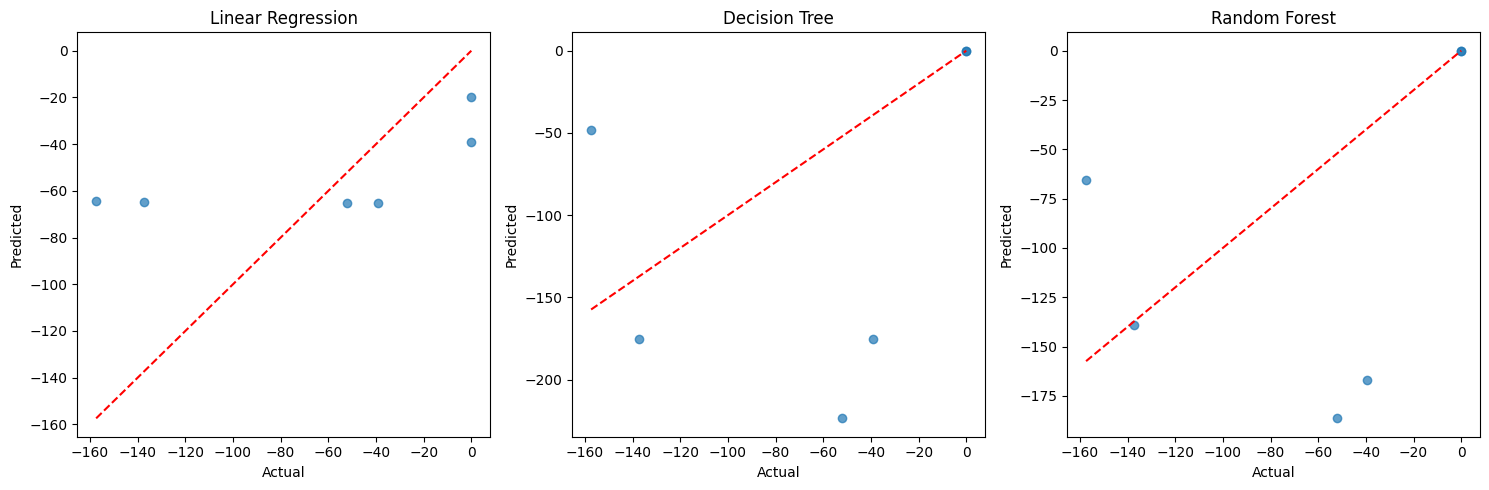

In [13]:
# Visualize results
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.scatter(y_test, lr_preds, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title("Linear Regression")
plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.subplot(1, 3, 2)
plt.scatter(y_test, dt_preds, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title("Decision Tree")
plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.subplot(1, 3, 3)
plt.scatter(y_test, rf_preds, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title("Random Forest")
plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.tight_layout()
plt.style.use("dark_background")
plt.show()

In [14]:
# Analyze coefficients
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_
})
intercept = pd.DataFrame({
    'Feature': ['Intercept'],
    'Coefficient': [lr_model.intercept_]
})
coef_df = pd.concat([intercept, coefficients], ignore_index=True)

print("Model Coefficients:")
print(coef_df)

Model Coefficients:
       Feature  Coefficient
0    Intercept   -67.803241
1  num_commits     0.067547
2    pageviews     0.307310


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29 entries, 0 to 76
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   num_commits  29 non-null     int64  
 1   pageviews    29 non-null     float64
 2   AVG(diff)    29 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 928.0 bytes
